that occur due to storm surges, and on the contributions of changes in MSL to variability in the extremes 

In [2]:
import sys
import pandas as pd
import os

sys.path.append('..')


In [4]:
## This code was copied from https://github.com/philiprt/GeslaDataset/blob/main/gesla.py

import pandas as pd
import xarray as xr
import warnings


class GeslaDataset:
    """A class for loading data from GESLA text files into convenient in-memory
    data objects. By default, single file requests are loaded into
    `pandas.DataFrame` objects, which are similar to in-memory spreadsheets.
    Multifile requests are loaded into `xarray.Dataset` objects, which are
    similar to in-memory NetCDF files."""

    def __init__(self, meta_file, data_path):
        """Initialize loading data from a GESLA database.

        Args:
            meta_file (string): path to the metadata file in .csv format.
            data_path (string): path to the directory containing GESLA data
                files.
        """
        self.meta = pd.read_csv(meta_file)
        self.meta.columns = [
            c.replace(" ", "_")
            .replace("(", "")
            .replace(")", "")
            .replace("/", "_")
            .lower()
            for c in self.meta.columns
        ]
        self.meta.loc[:, "start_date_time"] = [
            pd.to_datetime(d) for d in self.meta.loc[:, "start_date_time"]
        ]
        self.meta.loc[:, "end_date_time"] = [
            pd.to_datetime(d) for d in self.meta.loc[:, "end_date_time"]
        ]
        self.meta.rename(columns={"file_name": "filename"}, inplace=True)
        self.data_path = data_path

    def file_to_pandas(self, filename, return_meta=True):
        """Read a GESLA data file into a pandas.DataFrame object. Metadata is
        returned as a pandas.Series object.

        Args:
            filename (string): name of the GESLA data file. Do not prepend path.
            return_meta (bool, optional): determines if metadata is returned as
                a second function output. Defaults to True.

        Returns:
            pandas.DataFrame: sea-level values and flags with datetime index.
            pandas.Series: record metadata. This return can be excluded by
                setting return_meta=False.
        """
        #with open(self.data_path + filename, "r") as f:
        with open(os.path.join(self.data_path, filename), "r") as f:
            data = pd.read_csv(
                f,
                skiprows=41,
                names=["date", "time", "sea_level", "qc_flag", "use_flag"],
                sep="\s+",
                parse_dates=[[0, 1]],
                index_col=0,
            )
            duplicates = data.index.duplicated()
            if duplicates.sum() > 0:
                data = data.loc[~duplicates]
                warnings.warn(
                    "Duplicate timestamps in file " + filename + " were removed.",
                )
            if return_meta:
                meta = self.meta.loc[self.meta.filename == filename].iloc[0]
                return data, meta
            else:
                return data

    def files_to_xarray(self, filenames):
        """Read a list of GESLA filenames into a xarray.Dataset object. The
        dataset includes variables containing metadata for each record.

        Args:
            filenames (list): list of filename strings.

        Returns:
            xarray.Dataset: data, flags, and metadata for each record.
        """
        data = xr.concat(
            [self.file_to_pandas(f, return_meta=False).to_xarray() for f in filenames],
            dim="station",
        )

        idx = [s.Index for s in self.meta.itertuples() if s.filename in filenames]
        meta = self.meta.loc[idx]
        meta.index = range(meta.index.size)
        meta.index.name = "station"
        data = data.assign({c: meta[c] for c in meta.columns})

        return data

    def load_N_closest(self, lat, lon, N=1, force_xarray=False):
        """Load the N closest GESLA records to a lat/lon location into a
        xarray.Dataset object. The dataset includes variables containing
        metadata for each record.

        Args:
            lat (float): latitude on the interval [-90, 90]
            lon (float): longitude on the interval [-180, 180]
            N (int, optional): number of locations to load. Defaults to 1.
            force_xarray (bool, optional): if N=1, the default behavior is to
                return a pandas.DataFrame object containing data/flags and a
                pandas.Series object containing metadata. Set this argument to
                True to return a xarray Dataset even if N=1. Defaults to False.

        Returns:
            xarray.Dataset: data, flags, and metadata for each record.
        """
        N = int(N)
        if N <= 0:
            raise Exception("Must specify N > 0")

        d = (self.meta.longitude - lon) ** 2 + (self.meta.latitude - lat) ** 2
        idx = d.sort_values().iloc[:N].index
        meta = self.meta.loc[idx]

        if (N > 1) or force_xarray:
            return self.files_to_xarray(meta.filename.tolist())

        else:
            data, meta = self.file_to_pandas(meta.filename.values[0])
            return data, meta

    def load_lat_lon_range(
        self,
        south_lat=-90,
        north_lat=90,
        west_lon=-180,
        east_lon=180,
        force_xarray=False,
    ):
        """Load GESLA records within a rectangular lat/lon range into a xarray.
        Dataset object.

        Args:
            south_lat (float, optional): southern extent of the range. Defaults
                to -90.
            north_lat (float, optional): northern extent of the range. Defaults
                to 90.
            west_lon (float, optional): western extent of the range. Defaults
                to -180.
            east_lon (float, optional): eastern extent of the range. Defaults
                to 180.
            force_xarray (bool, optional): if there is only one record in the
                lat/lon range, the default behavior is to return a
                pandas.DataFrame object containing data/flags and a
                pandas.Series object containing metadata. Set this argument to
                True to return a xarray.Dataset even if only one record is
                selected. Defaults to False.

        Returns:
            xarray.Dataset: data, flags, and metadata for each record.
        """
        if west_lon > 0 & east_lon < 0:
            lon_bool = (self.meta.longitude >= west_lon) | (
                self.meta.longitude <= east_lon
            )
        else:
            lon_bool = (self.meta.longitude >= west_lon) & (
                self.meta.longitude <= east_lon
            )
        lat_bool = (self.meta.latitude >= south_lat) & (self.meta.latitude <= north_lat)
        meta = self.meta.loc[lon_bool & lat_bool]

        if (meta.index.size > 1) or force_xarray:
            return self.files_to_xarray(meta.filename.tolist())

        else:
            data, meta = self.file_to_pandas(meta.filename.values[0])
            return data, meta

<>:61: SyntaxWarning: invalid escape sequence '\s'
<>:61: SyntaxWarning: invalid escape sequence '\s'
/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_90608/372985823.py:61: SyntaxWarning: invalid escape sequence '\s'
  sep="\s+",


In [3]:
meta_file = "/Users/lb962/Downloads/GESLA3_ALL.csv"
data_path = "/Users/lb962/Downloads/GESLA3.0_ALL"
g3 = GeslaDataset(meta_file=meta_file, data_path=data_path)

In [25]:
import os
import numpy as np

#latitudes = [(48, 55), (55,60), (60, 65)]
#longitudes = [(-11.5, -5), (-5, 3), (3, 9), (9, 15)]

latitudes = [(60,62), (62,65)]
longitudes = [(-11.5, -5), (-5, 10)]
# Define a regular time axis
common_time = pd.date_range(start="1950-01-01", end="2024-12-31 23:00", freq="1H")

output_directory = "/Users/lb962/Documents/GitHub/ESL/data/GESLA_NS"
# Global counter for assigning unique station IDs
next_station_id = 1

for lat_range in latitudes:
    for lon_range in longitudes:
        output_file = os.path.join(
            output_directory,
            f"GESLA3_NorthSea_{lat_range[0]}_{lat_range[1]}_{lon_range[0]}_{lon_range[1]}.nc"
        )

        try:
            # Load data
            gesla_data_chunk = g3.load_lat_lon_range(
                south_lat=lat_range[0],
                north_lat=lat_range[1],
                west_lon=lon_range[0],
                east_lon=lon_range[1],
            )

            # Mask sea_level where use_flag is NaN
            mask = np.isnan(gesla_data_chunk["use_flag"])
            sea_level_cleaned = gesla_data_chunk["sea_level"].where(~mask)

            # Convert to float32
            sea_level_cleaned = sea_level_cleaned.astype("float32")

            # Reindex to common time axis, filling missing values with NaN
            sea_level_cleaned = sea_level_cleaned.reindex(date_time=common_time)
            # Reindex to a common hourly time axis
            sea_level_cleaned = sea_level_cleaned.reindex(date_time=common_time)

            sea_level_ds = sea_level_cleaned.to_dataset(name="sea_level")

            # Get number of stations in this chunk
            n_stations = sea_level_cleaned.sizes["station"]

            # Assign global unique station IDs
            station_ids = np.arange(next_station_id, next_station_id + n_stations)
            next_station_id += n_stations  # update global counter
            
            sea_level_ds = sea_level_ds.assign_coords(
                station=("station", station_ids),
                latitude=("station", gesla_data_chunk["latitude"].values),
                longitude=("station", gesla_data_chunk["longitude"].values),
            )
            # Create single-variable dataset
   
            #sea_level_ds["latitude"] = gesla_data_chunk["latitude"]
            #sea_level_ds["longitude"] = gesla_data_chunk["longitude"]
            # Save to NetCDF
            sea_level_ds.to_netcdf(output_file)

            print(f"✅ Saved: {output_file}")

        except Exception as e:
            print(f"❌ Failed to save: {output_file}")
            print(f"   Reason: {e}")

❌ Failed to save: /Users/lb962/Documents/GitHub/ESL/data/GESLA_NS/GESLA3_NorthSea_60_62_-11.5_-5.nc
   Reason: index 0 is out of bounds for axis 0 with size 0


/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_90608/372985823.py:68: UserWarning: Duplicate timestamps in file maloy-may-nor-nhs were removed.
  warnings.warn(


✅ Saved: /Users/lb962/Documents/GitHub/ESL/data/GESLA_NS/GESLA3_NorthSea_60_62_-5_10.nc
❌ Failed to save: /Users/lb962/Documents/GitHub/ESL/data/GESLA_NS/GESLA3_NorthSea_62_65_-11.5_-5.nc
   Reason: index 0 is out of bounds for axis 0 with size 0


/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_90608/372985823.py:68: UserWarning: Duplicate timestamps in file kristiansund-ksu-nor-nhs were removed.
  warnings.warn(
/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_90608/372985823.py:68: UserWarning: Duplicate timestamps in file alesund-aes-nor-nhs were removed.
  warnings.warn(


✅ Saved: /Users/lb962/Documents/GitHub/ESL/data/GESLA_NS/GESLA3_NorthSea_62_65_-5_10.nc


In [22]:
import os
import numpy as np

#latitudes = [(48, 55), (55,60), (60, 65)]
#longitudes = [(-11.5, -5), (-5, 3), (3, 9), (9, 15)]

latitudes = [(45, 49), (49,50), (50,51), (51,52), (52,53), (54,55), (55,56), (56,57), (57,58), (58,59), (59,60)]
longitudes = [(-11.5, -5), (-5, 10)]
# Define a regular time axis
common_time = pd.date_range(start="1950-01-01", end="2024-12-31 23:00", freq="1H")

output_directory = "/Users/lb962/Documents/GitHub/ESL/data/GESLA_NS"
# Global counter for assigning unique station IDs
next_station_id = 1

for lat_range in latitudes:
    for lon_range in longitudes:
        output_file = os.path.join(
            output_directory,
            f"GESLA3_NorthSea_{lat_range[0]}_{lat_range[1]}_{lon_range[0]}_{lon_range[1]}.nc"
        )

        try:
            # Load data
            gesla_data_chunk = g3.load_lat_lon_range(
                south_lat=lat_range[0],
                north_lat=lat_range[1],
                west_lon=lon_range[0],
                east_lon=lon_range[1],
            )

            # Mask sea_level where use_flag is NaN
            mask = np.isnan(gesla_data_chunk["use_flag"])
            sea_level_cleaned = gesla_data_chunk["sea_level"].where(~mask)

            # Convert to float32
            sea_level_cleaned = sea_level_cleaned.astype("float32")

            # Reindex to common time axis, filling missing values with NaN
            sea_level_cleaned = sea_level_cleaned.reindex(date_time=common_time)
            # Reindex to a common hourly time axis
            sea_level_cleaned = sea_level_cleaned.reindex(date_time=common_time)

            sea_level_ds = sea_level_cleaned.to_dataset(name="sea_level")

            # Get number of stations in this chunk
            n_stations = sea_level_cleaned.sizes["station"]

            # Assign global unique station IDs
            station_ids = np.arange(next_station_id, next_station_id + n_stations)
            next_station_id += n_stations  # update global counter
            
            sea_level_ds = sea_level_ds.assign_coords(
                station=("station", station_ids),
                latitude=("station", gesla_data_chunk["latitude"].values),
                longitude=("station", gesla_data_chunk["longitude"].values),
            )
            # Create single-variable dataset
   
            #sea_level_ds["latitude"] = gesla_data_chunk["latitude"]
            #sea_level_ds["longitude"] = gesla_data_chunk["longitude"]
            # Save to NetCDF
            sea_level_ds.to_netcdf(output_file)

            print(f"✅ Saved: {output_file}")

        except Exception as e:
            print(f"❌ Failed to save: {output_file}")
            print(f"   Reason: {e}")

❌ Failed to save: /Users/lb962/Documents/GitHub/ESL/data/GESLA_NS/GESLA3_NorthSea_45_49_-11.5_-5.nc
   Reason: index 0 is out of bounds for axis 0 with size 0
✅ Saved: /Users/lb962/Documents/GitHub/ESL/data/GESLA_NS/GESLA3_NorthSea_45_49_-5_10.nc
✅ Saved: /Users/lb962/Documents/GitHub/ESL/data/GESLA_NS/GESLA3_NorthSea_49_50_-11.5_-5.nc
✅ Saved: /Users/lb962/Documents/GitHub/ESL/data/GESLA_NS/GESLA3_NorthSea_49_50_-5_10.nc
✅ Saved: /Users/lb962/Documents/GitHub/ESL/data/GESLA_NS/GESLA3_NorthSea_50_51_-11.5_-5.nc


/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_90608/372985823.py:68: UserWarning: Duplicate timestamps in file arun_platform-arn-gbr-cco were removed.
  warnings.warn(


✅ Saved: /Users/lb962/Documents/GitHub/ESL/data/GESLA_NS/GESLA3_NorthSea_50_51_-5_10.nc
✅ Saved: /Users/lb962/Documents/GitHub/ESL/data/GESLA_NS/GESLA3_NorthSea_51_52_-11.5_-5.nc


/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_90608/372985823.py:68: UserWarning: Duplicate timestamps in file vlissingen-vlissgn-nld-rws were removed.
  warnings.warn(
/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_90608/372985823.py:68: UserWarning: Duplicate timestamps in file hoek_van_holland-hoekvhld-nld-rws were removed.
  warnings.warn(
/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_90608/372985823.py:68: UserWarning: Duplicate timestamps in file dordrecht-dordt-nld-rws were removed.
  warnings.warn(
/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_90608/372985823.py:68: UserWarning: Duplicate timestamps in file roompot_buiten-roompbtn-nld-rws were removed.
  warnings.warn(
/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_90608/372985823.py:68: UserWarning: Duplicate timestamps in file lichteiland_goeree-lichtelgre-nld-rws were removed.
  warnings.warn(


✅ Saved: /Users/lb962/Documents/GitHub/ESL/data/GESLA_NS/GESLA3_NorthSea_51_52_-5_10.nc
✅ Saved: /Users/lb962/Documents/GitHub/ESL/data/GESLA_NS/GESLA3_NorthSea_52_53_-11.5_-5.nc


/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_90608/372985823.py:68: UserWarning: Duplicate timestamps in file den_helder-denhdr-nld-rws were removed.
  warnings.warn(


✅ Saved: /Users/lb962/Documents/GitHub/ESL/data/GESLA_NS/GESLA3_NorthSea_52_53_-5_10.nc
✅ Saved: /Users/lb962/Documents/GitHub/ESL/data/GESLA_NS/GESLA3_NorthSea_54_55_-11.5_-5.nc
✅ Saved: /Users/lb962/Documents/GitHub/ESL/data/GESLA_NS/GESLA3_NorthSea_54_55_-5_10.nc
✅ Saved: /Users/lb962/Documents/GitHub/ESL/data/GESLA_NS/GESLA3_NorthSea_55_56_-11.5_-5.nc
✅ Saved: /Users/lb962/Documents/GitHub/ESL/data/GESLA_NS/GESLA3_NorthSea_55_56_-5_10.nc
✅ Saved: /Users/lb962/Documents/GitHub/ESL/data/GESLA_NS/GESLA3_NorthSea_56_57_-11.5_-5.nc
✅ Saved: /Users/lb962/Documents/GitHub/ESL/data/GESLA_NS/GESLA3_NorthSea_56_57_-5_10.nc
✅ Saved: /Users/lb962/Documents/GitHub/ESL/data/GESLA_NS/GESLA3_NorthSea_57_58_-11.5_-5.nc


/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_90608/372985823.py:68: UserWarning: Duplicate timestamps in file aberdeen-abe-gbr-bodc were removed.
  warnings.warn(


✅ Saved: /Users/lb962/Documents/GitHub/ESL/data/GESLA_NS/GESLA3_NorthSea_57_58_-5_10.nc
✅ Saved: /Users/lb962/Documents/GitHub/ESL/data/GESLA_NS/GESLA3_NorthSea_58_59_-11.5_-5.nc
✅ Saved: /Users/lb962/Documents/GitHub/ESL/data/GESLA_NS/GESLA3_NorthSea_58_59_-5_10.nc
❌ Failed to save: /Users/lb962/Documents/GitHub/ESL/data/GESLA_NS/GESLA3_NorthSea_59_60_-11.5_-5.nc
   Reason: index 0 is out of bounds for axis 0 with size 0
❌ Failed to save: /Users/lb962/Documents/GitHub/ESL/data/GESLA_NS/GESLA3_NorthSea_59_60_-5_10.nc
   Reason: index 0 is out of bounds for axis 0 with size 0


find out

In [1]:
import os
import xarray as xr

In [22]:
# Set directory
output_directory = "/Users/lb962/Documents/GitHub/ESL/data/GESLA_NS"

# Get list of all NetCDF files in the directory
nc_files = [os.path.join(output_directory, f) for f in os.listdir(output_directory) if f.endswith('.nc')]

# Load and concatenate datasets along a new dimension if needed
ds = xr.open_mfdataset(nc_files, combine='by_coords')  # or combine='nested' with concat_dim='time' if needed


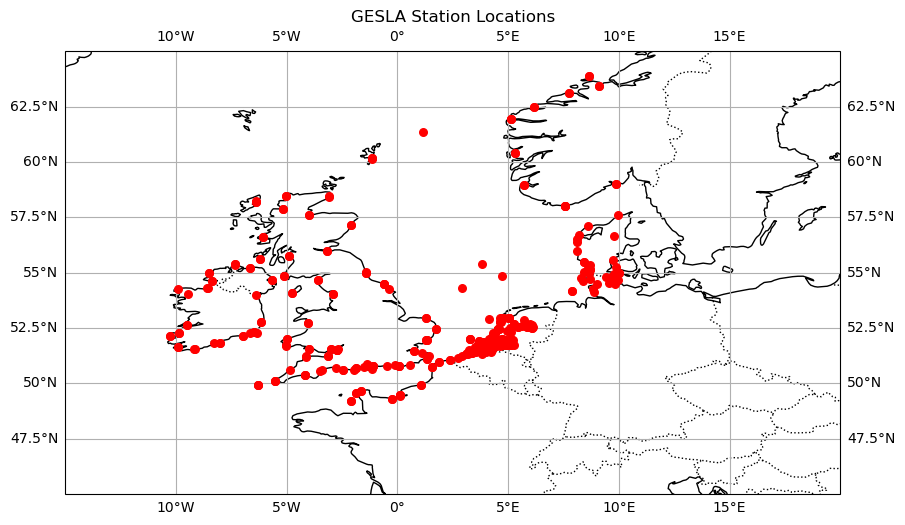

In [3]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Extract station coordinates (load from Dask arrays if needed)
lats = ds['latitude'].values
lons = ds['longitude'].values

# Create map
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add map features
ax.set_extent([-15, 20, 45, 65], crs=ccrs.PlateCarree())  # zoom to Europe/North Sea
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=":")
ax.gridlines(draw_labels=True)

# Plot station locations
ax.scatter(lons, lats, color='red', s=30, marker='o', transform=ccrs.PlateCarree(), zorder=5)

plt.title("GESLA Station Locations")
plt.show()


In [23]:
import cartopy.io.shapereader as shpreader
import shapely
from shapely.geometry import Point
import numpy as np

# Step 1: Load raw coastline geometries
reader = shpreader.natural_earth(resolution='10m', category='physical', name='coastline')
coastlines = list(shpreader.Reader(reader).geometries())  # list of LineStrings or MultiLineStrings

# Step 2: Extract station coordinates
lats = ds['latitude'].values
lons = ds['longitude'].values
station_ids = ds['station'].values

# Step 3: Convert to Shapely Points
station_points = [Point(lon, lat) for lon, lat in zip(lons, lats)]

# Step 4: For each point, compute min distance to any coastline segment
# This avoids slow union operation

def min_distance_to_coast(point, coastlines):
    return min(geom.distance(point) for geom in coastlines)

distances = np.array([min_distance_to_coast(p, coastlines) for p in station_points])

# Step 5: Keep stations within e.g. 0.1 degrees (~10 km)
threshold_deg = 0.1
coastal_mask = distances <= threshold_deg

# Step 6: Filter dataset
ds_coastal = ds.sel(station=coastal_mask)

print(f"✅ Kept {ds_coastal.sizes['station']} coastal stations out of {ds.sizes['station']}")


✅ Kept 287 coastal stations out of 375


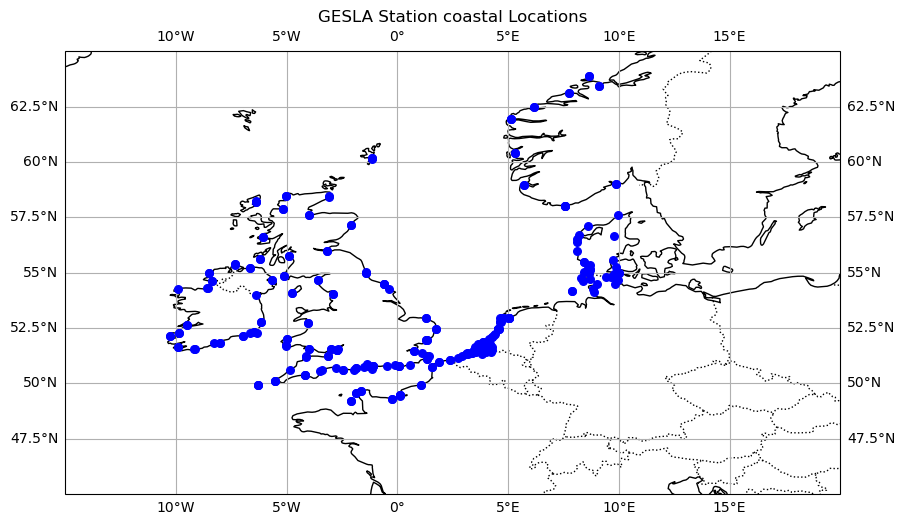

In [24]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Extract station coordinates (load from Dask arrays if needed)
lats = ds_coastal['latitude'].values
lons = ds_coastal['longitude'].values

# Create map
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add map features
ax.set_extent([-15, 20, 45, 65], crs=ccrs.PlateCarree())  # zoom to Europe/North Sea
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=":")
ax.gridlines(draw_labels=True)

# Plot station locations
ax.scatter(lons, lats, color='blue', s=30, marker='o', transform=ccrs.PlateCarree(), zorder=5)

plt.title("GESLA Station coastal Locations")
plt.show()

In [54]:
import numpy as np

# Step 1: Compute mean and std per station (over time)
mean = ds_coastal['sea_level'].mean(dim='date_time')
std = ds_coastal['sea_level'].std(dim='date_time')

# Step 2: Broadcast mean and std to match sea_level shape
mean_exp = mean.expand_dims({'date_time': ds_coastal.dims['date_time']}).transpose('station', 'date_time')
std_exp = std.expand_dims({'date_time': ds_coastal.dims['date_time']}).transpose('station', 'date_time')

# Step 3: Apply mask to remove outliers (outside ±2 std)
ds_coastal['sea_level'] = ds_coastal['sea_level'].where(
    (ds['sea_level'] >= (mean_exp - 3 * std_exp)) &
    (ds['sea_level'] <= (mean_exp + 3 * std_exp)),
    np.nan
)

# MSl reference
ds_coastal = ds_coastal - ds_coastal.mean(dim='date_time')

In [55]:
# Step 2: Restrict to 1950–2024
sea_level_subset = ds_coastal['sea_level'].sel(
    date_time=slice("1950-01-01", "2024-12-31")
)

# Step 3: Group by year and count valid values
# This gives: (year, station)
valid_counts_per_year = sea_level_subset.groupby('date_time.year').count(dim='date_time')

# Step 4: Set thresholds
required_years = 10
min_hours = int(365.25 * 24 * 0.70)  # ~7010 hours/year

# Step 5: Count number of valid years per station (where yearly count >= min_hours)
good_years_mask = valid_counts_per_year >= min_hours
num_good_years = good_years_mask.sum(dim='year')  # shape: (station,)

# Step 6: Compute the boolean mask
station_mask = (num_good_years >= required_years).compute()

# Step 7: Use it to index station coordinates
stations_to_keep = ds_coastal['station'].values[station_mask]

# Step 8: Filter the dataset
ds_filtered = ds_coastal.sel(station=stations_to_keep)

print(f"✅ Kept {ds_filtered.sizes['station']} stations out of {ds.sizes['station']}")


/Users/lb962/miniconda3/envs/ESL/lib/python3.12/site-packages/dask/array/numpy_compat.py:53: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


✅ Kept 188 stations out of 375


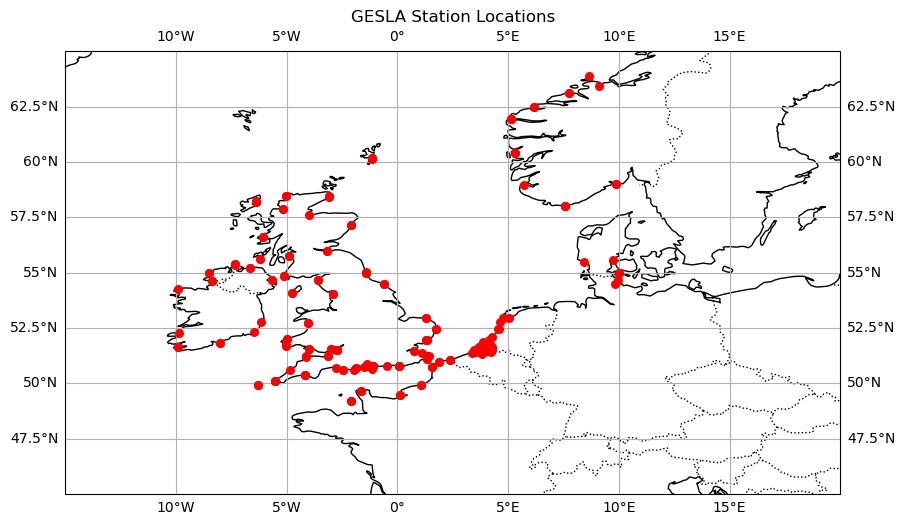

In [56]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Extract station coordinates (load from Dask arrays if needed)
lats = ds_filtered['latitude'].values
lons = ds_filtered['longitude'].values

# Create map
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add map features
ax.set_extent([-15, 20, 45, 65], crs=ccrs.PlateCarree())  # zoom to Europe/North Sea
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=":")
ax.gridlines(draw_labels=True)

# Plot station locations
ax.scatter(lons, lats, color='red', s=30, marker='o', transform=ccrs.PlateCarree(), zorder=5)

plt.title("GESLA Station Locations")
plt.show()

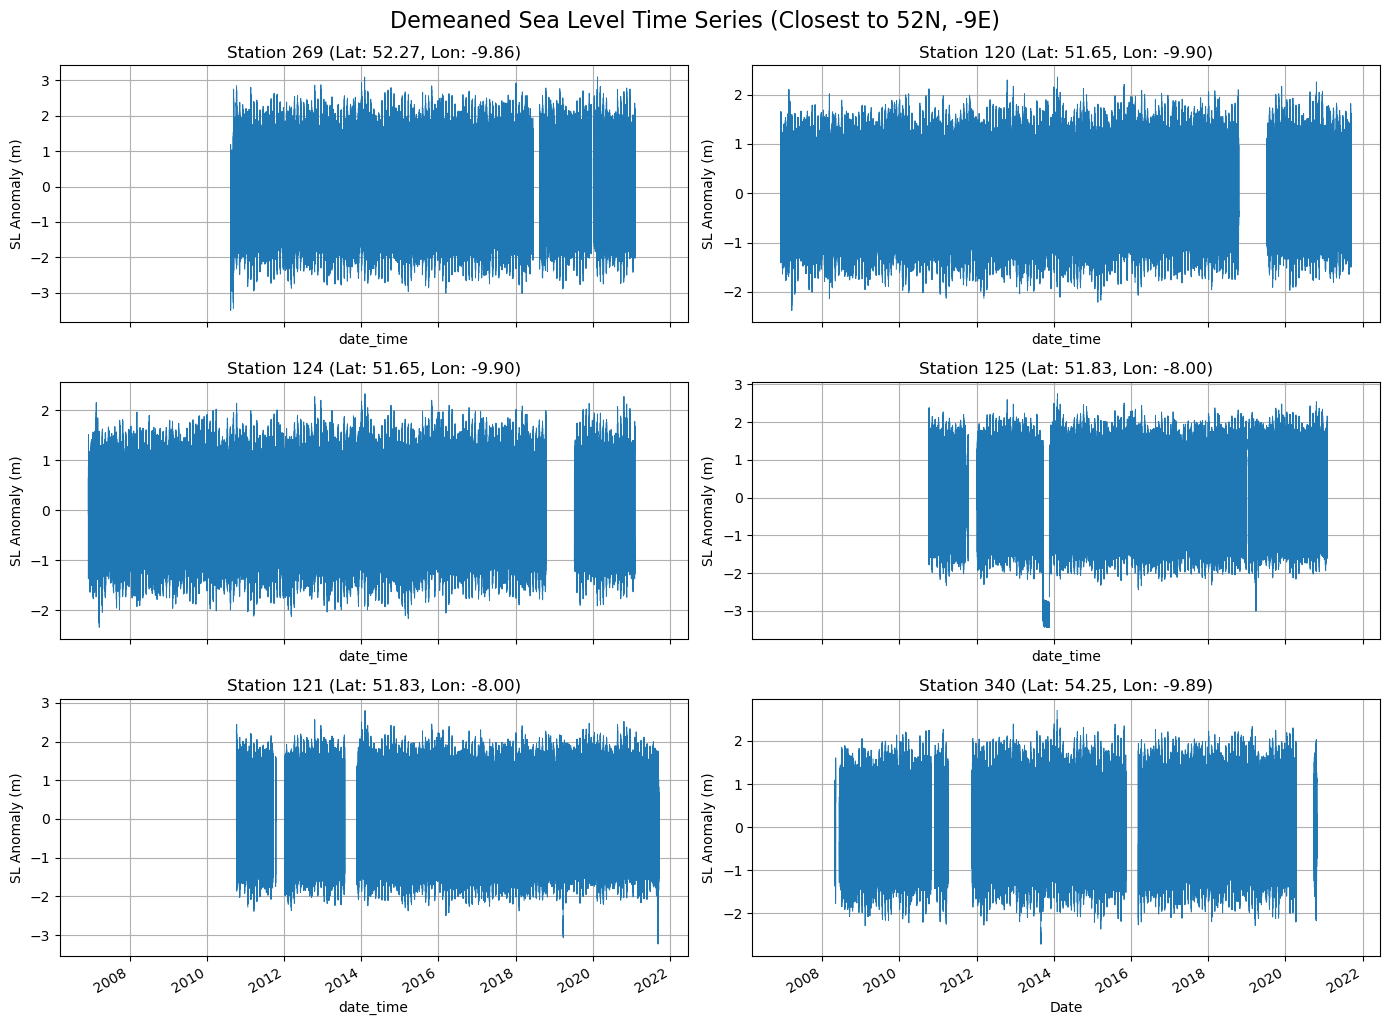

In [57]:
import numpy as np
import matplotlib.pyplot as plt

# Target location (latitude 52N, longitude -9E)
target_lat = 52.0
target_lon = -9.0

# Step 1: Extract station coordinates
lats = ds_filtered['latitude'].values
lons = ds_filtered['longitude'].values

# Step 2: Compute Euclidean distance
distances = np.sqrt((lats - target_lat)**2 + (lons - target_lon)**2)

# Step 3: Get indices of the 6 closest stations
closest_indices = np.argsort(distances)[:6]
closest_station_ids = ds_filtered['station'].values[closest_indices]

# Step 4: Plot each station in a subplot
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 10), sharex=True)
axes = axes.flatten()  # to index easily in a loop

for i, station_id in enumerate(closest_station_ids):
    ax = axes[i]
    ts = ds_filtered['sea_level'].sel(station=station_id)
    ts_anom = ts - ts.mean(dim='date_time')

    ts_anom.plot(ax=ax, linewidth=0.7)
    ax.set_title(f"Station {station_id} (Lat: {lats[closest_indices[i]]:.2f}, Lon: {lons[closest_indices[i]]:.2f})")
    ax.set_ylabel("SL Anomaly (m)")
    ax.grid(True)

# Shared x-label
axes[-1].set_xlabel("Date")

plt.tight_layout()
plt.suptitle("Demeaned Sea Level Time Series (Closest to 52N, -9E)", y=1.02, fontsize=16)
plt.show()

In [58]:
valid_counts = ds_filtered['sea_level'].count(dim='date_time')
total_counts = ds_filtered['date_time'].size
coverage_ratio = (valid_counts / total_counts) * 100

print("📊 Data coverage (% per station):")
print(coverage_ratio.to_series().describe())  # pandas-style summary


📊 Data coverage (% per station):


/Users/lb962/miniconda3/envs/ESL/lib/python3.12/site-packages/dask/array/numpy_compat.py:53: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


count    188.000000
mean      41.477793
std       21.771284
min       12.402351
25%       22.923435
50%       37.177013
75%       55.515388
max       93.176578
Name: sea_level, dtype: float64


In [63]:
# Cap extreme values before computing annual max
ds_filtered['sea_level'] = ds_filtered['sea_level'].where(
    (ds_filtered['sea_level'] > -5) & (ds_filtered['sea_level'] < 10)  # sensible limits in meters
)


/Users/lb962/miniconda3/envs/ESL/lib/python3.12/site-packages/dask/array/numpy_compat.py:53: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/Users/lb962/miniconda3/envs/ESL/lib/python3.12/site-packages/dask/array/numpy_compat.py:53: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/Users/lb962/miniconda3/envs/ESL/lib/python3.12/site-packages/dask/array/numpy_compat.py:53: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/Users/lb962/miniconda3/envs/ESL/lib/python3.12/site-packages/dask/array/numpy_compat.py:53: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/Users/lb962/miniconda3/envs/ESL/lib/python3.12/site-packages/dask/array/numpy_compat.py:53: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/Users/lb962/miniconda3/envs/ESL/lib/python3.12/site-packages/dask/array/numpy_compat.py:53: RuntimeWarning: invalid value encount

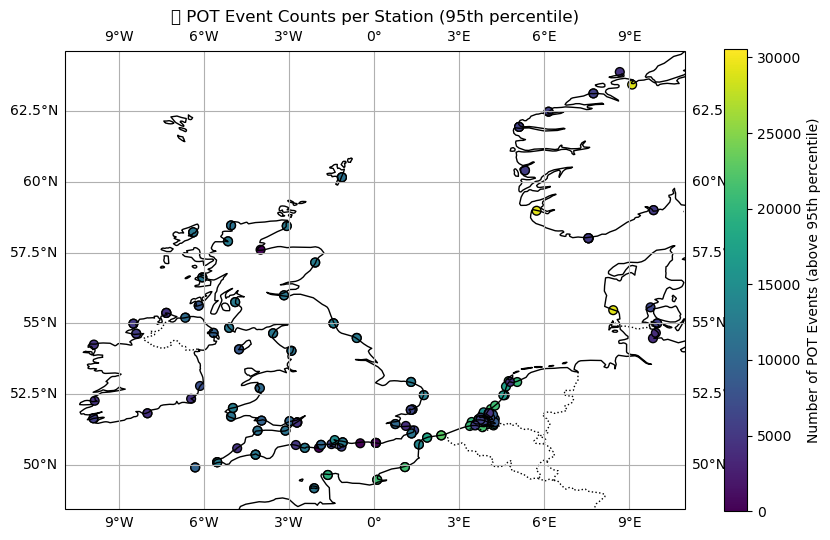

/Users/lb962/miniconda3/envs/ESL/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:538: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  super()._update_title_position(renderer)
/Users/lb962/miniconda3/envs/ESL/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:538: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  super()._update_title_position(renderer)
/Users/lb962/miniconda3/envs/ESL/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:535: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  return super().draw(renderer=renderer, **kwargs)


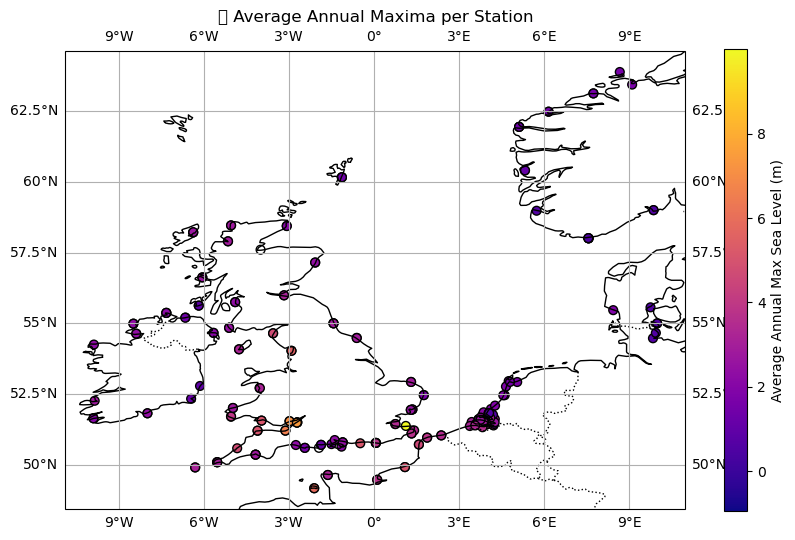

In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# 1. Define threshold level for POT (e.g., 95th percentile)
thresholds = ds_filtered['sea_level'].quantile(0.95, dim='date_time')

# 2. Count POT events (number of times above threshold per station)
pot_events = (ds_filtered['sea_level'] > thresholds).sum(dim='date_time')

# 3. Compute annual maxima
annual_max = ds_filtered['sea_level'].groupby('date_time.year').max(dim='date_time')

# 4. Compute average annual max (AAM)
aam = annual_max.mean(dim='year')

# 5. Extract station locations
lons = ds_filtered['longitude'].values
lats = ds_filtered['latitude'].values

# 6. Convert data to NumPy arrays
pot_counts = pot_events.values
aam_values = aam.values
station_ids = ds_filtered['station'].values

# --- Plot 1: POT Events Map ---
fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.gridlines(draw_labels=True)

sc1 = ax.scatter(lons, lats, c=pot_counts, cmap='viridis', s=40, edgecolor='k', transform=ccrs.PlateCarree())
plt.colorbar(sc1, ax=ax, label='Number of POT Events (above 95th percentile)')
plt.title("🌊 POT Event Counts per Station (95th percentile)")
plt.show()

# --- Plot 2: Average Annual Maxima Map ---
fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.gridlines(draw_labels=True)

sc2 = ax.scatter(lons, lats, c=aam_values, cmap='plasma', s=40, edgecolor='k', transform=ccrs.PlateCarree())
plt.colorbar(sc2, ax=ax, label='Average Annual Max Sea Level (m)')
plt.title("📈 Average Annual Maxima per Station")
plt.show()


/Users/lb962/miniconda3/envs/ESL/lib/python3.12/site-packages/dask/array/numpy_compat.py:53: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/Users/lb962/miniconda3/envs/ESL/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:538: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from current font.
  super()._update_title_position(renderer)
/Users/lb962/miniconda3/envs/ESL/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:538: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from current font.
  super()._update_title_position(renderer)
/Users/lb962/miniconda3/envs/ESL/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:535: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from current font.
  return super().draw(renderer=renderer, **kwargs)


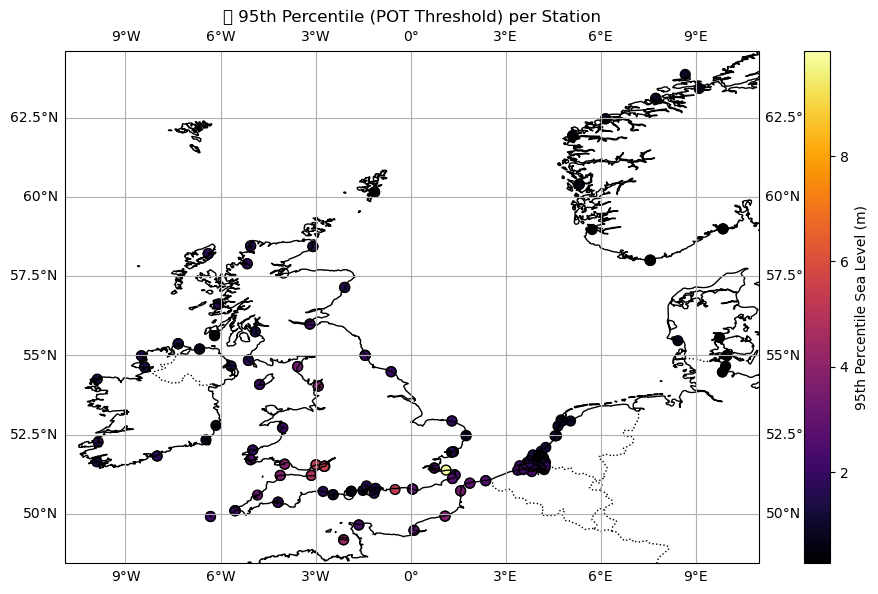

In [65]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Step 1: Calculate 95th percentile per station (POT threshold)
pot_threshold = ds_filtered['sea_level'].quantile(0.95, dim='date_time')

# Step 2: Extract coordinates and values
lons = ds_filtered['longitude'].values
lats = ds_filtered['latitude'].values
pot_values = pot_threshold.values

# Step 3: Plot map
fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines(resolution='10m')
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.gridlines(draw_labels=True)

sc = ax.scatter(
    lons, lats,
    c=pot_values,
    cmap='inferno',
    s=50,
    edgecolor='k',
    transform=ccrs.PlateCarree()
)

plt.colorbar(sc, ax=ax, label='95th Percentile Sea Level (m)')
plt.title('🌊 95th Percentile (POT Threshold) per Station')
plt.tight_layout()
plt.show()


/Users/lb962/miniconda3/envs/ESL/lib/python3.12/site-packages/dask/array/numpy_compat.py:53: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/Users/lb962/miniconda3/envs/ESL/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:538: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from current font.
  super()._update_title_position(renderer)
/Users/lb962/miniconda3/envs/ESL/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:538: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from current font.
  super()._update_title_position(renderer)
/Users/lb962/miniconda3/envs/ESL/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:535: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from current font.
  return super().draw(renderer=renderer, **kwargs)


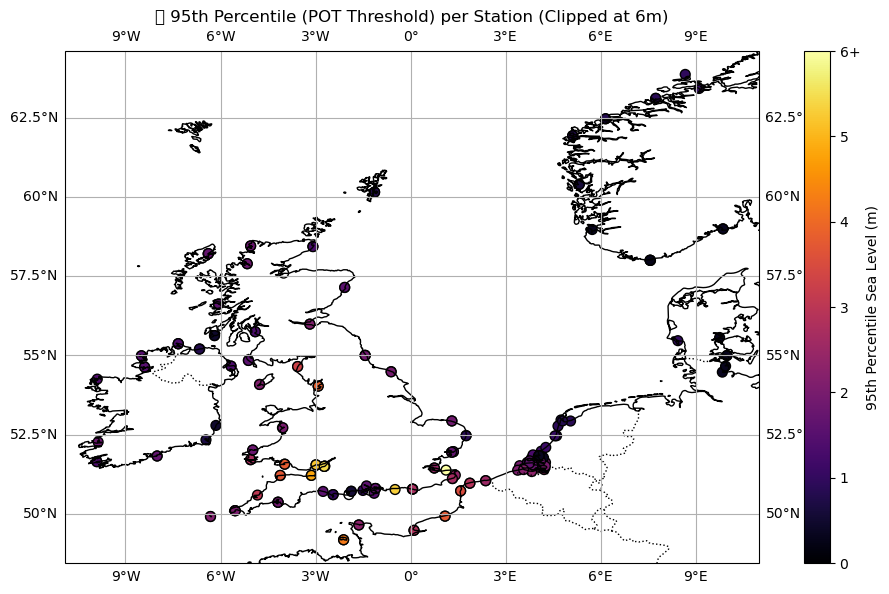

In [66]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Step 1: Calculate 95th percentile per station (POT threshold)
pot_threshold = ds_filtered['sea_level'].quantile(0.95, dim='date_time')

# Step 2: Extract coordinates and values
lons = ds_filtered['longitude'].values
lats = ds_filtered['latitude'].values
pot_values = pot_threshold.values

# Step 3: Clip values at 8m for color scaling
clipped_pot = np.clip(pot_values, a_min=None, a_max=6)

# Step 4: Plot
fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines(resolution='10m')
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.gridlines(draw_labels=True)

# Scatter plot with clipped values
sc = ax.scatter(
    lons, lats,
    c=clipped_pot,
    cmap='inferno',
    s=50,
    edgecolor='k',
    transform=ccrs.PlateCarree(),
    vmin=0,
    vmax=6
)

# Step 5: Custom colorbar
cb = plt.colorbar(sc, ax=ax)
tick_locs = np.linspace(0, 6, num=7)  # 0 to 8 by 1
tick_labels = [str(int(t)) for t in tick_locs[:-1]] + ['6+']
cb.set_ticks(tick_locs)
cb.set_ticklabels(tick_labels)
cb.set_label('95th Percentile Sea Level (m)')

plt.title('🌊 95th Percentile (POT Threshold) per Station (Clipped at 6m)')
plt.tight_layout()
plt.show()


/Users/lb962/miniconda3/envs/ESL/lib/python3.12/site-packages/dask/array/numpy_compat.py:53: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/Users/lb962/miniconda3/envs/ESL/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:538: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from current font.
  super()._update_title_position(renderer)
/Users/lb962/miniconda3/envs/ESL/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:538: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from current font.
  super()._update_title_position(renderer)
/Users/lb962/miniconda3/envs/ESL/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:535: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from current font.
  return super().draw(renderer=renderer, **kwargs)


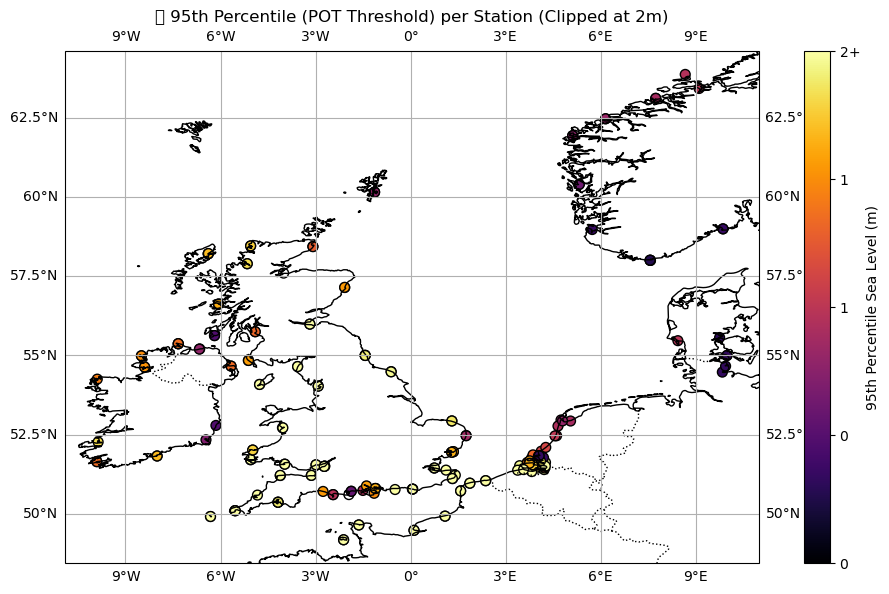

In [68]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Step 1: Calculate 95th percentile per station (POT threshold)
pot_threshold = ds_filtered['sea_level'].quantile(0.95, dim='date_time')

# Step 2: Extract coordinates and values
lons = ds_filtered['longitude'].values
lats = ds_filtered['latitude'].values
pot_values = pot_threshold.values

# Step 3: Clip values at 8m for color scaling
clipped_pot = np.clip(pot_values, a_min=None, a_max=2)

# Step 4: Plot
fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines(resolution='10m')
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.gridlines(draw_labels=True)

# Scatter plot with clipped values
sc = ax.scatter(
    lons, lats,
    c=clipped_pot,
    cmap='inferno',
    s=50,
    edgecolor='k',
    transform=ccrs.PlateCarree(),
    vmin=0,
    vmax=2
)

# Step 5: Custom colorbar
cb = plt.colorbar(sc, ax=ax)
tick_locs = np.linspace(0, 2, num=5)  # 0 to 8 by 1
tick_labels = [str(int(t)) for t in tick_locs[:-1]] + ['2+']
cb.set_ticks(tick_locs)
cb.set_ticklabels(tick_labels)
cb.set_label('95th Percentile Sea Level (m)')

plt.title('🌊 95th Percentile (POT Threshold) per Station (Clipped at 2m)')
plt.tight_layout()
plt.show()


# save

In [70]:
encoding = {
    'sea_level': {
        'zlib': True,
        'complevel': 4,
        'dtype': 'float32',
        'chunksizes': (32, 8760)  # ~monthly chunks; tweak as needed
    }
}

ds_filtered.to_netcdf(
    "filtered_GESLA_sea_level.nc",
    format="NETCDF4",
    encoding=encoding
)


/Users/lb962/miniconda3/envs/ESL/lib/python3.12/site-packages/dask/array/numpy_compat.py:53: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


In [69]:
ds_filtered

<xarray.Dataset>
Dimensions:    (date_time: 657456, station: 188)
Coordinates:
  * date_time  (date_time) datetime64[ns] 1950-01-01 ... 2024-12-31T23:00:00
  * station    (station) int64 1 2 3 4 5 6 7 8 ... 420 421 422 423 424 425 426
    latitude   (station) float64 dask.array<chunksize=(8,), meta=np.ndarray>
    longitude  (station) float64 dask.array<chunksize=(8,), meta=np.ndarray>
Data variables:
    sea_level  (station, date_time) float32 dask.array<chunksize=(8, 657456), meta=np.ndarray>

In [120]:
import pyextremes
from pyextremes import EVA

In [121]:
# Initialize EVA object
eva_data = df_hourly.sea_level.squeeze()
model = EVA(data=eva_data)
model

/Users/lb962/miniconda3/envs/ESL/lib/python3.12/site-packages/pyextremes/eva.py:131: RuntimeWarning: 52,776 Null values found in `data` - removing invalid entries
  warnings.warn(message=message, category=RuntimeWarning)


                           Univariate Extreme Value Analysis                            
                                      Source Data                                       
----------------------------------------------------------------------------------------
Data label:                     sea_level      Size:                             830,401
Start:                       January 1920      End:                        December 2016
                                     Extreme Values                                     
----------------------------------------------------------------------------------------
Extreme values have not been extracted
                                         Model                                          
----------------------------------------------------------------------------------------
Model has not been fit to the extremes

                           Univariate Extreme Value Analysis                            
                                      Source Data                                       
----------------------------------------------------------------------------------------
Data label:                     sea_level      Size:                             830,401
Start:                       January 1920      End:                        December 2016
                                     Extreme Values                                     
----------------------------------------------------------------------------------------
Count:                                 98      Extraction method:                     BM
Type:                                high      Block size:             365 days 05:49:12
                                         Model                                          
----------------------------------------------------------------------------------------
Model has not been fi

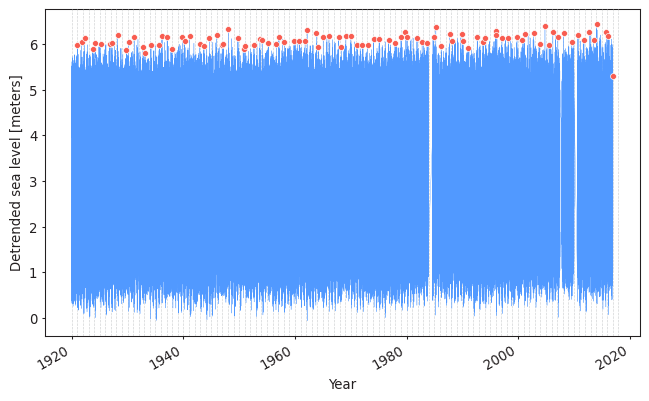

In [123]:
# Extract extreme values by annual block maxima approach
model.get_extremes(
    method="BM",
    extremes_type="high",
    block_size="365.2425D",
    errors="raise",
)
print(model)

# Plot block maxima
model.plot_extremes()
plt.xlabel("Year")
plt.ylabel("Detrended sea level [meters]")
#plt.savefig("plots/gev/1_annual_block_maxima.png")
plt.show()

In [125]:
# Fit the model extremes to GEV distribution using MCMC
model.fit_model(
    model="Emcee",
    #model = "MLE", # alternate model 
    distribution="genextreme",
    n_samples = 10_000,
    progress=True
)
print(model)

100%|██████████| 10000/10000 [01:31<00:00, 108.73it/s]


                           Univariate Extreme Value Analysis                            
                                      Source Data                                       
----------------------------------------------------------------------------------------
Data label:                     sea_level      Size:                             830,401
Start:                       January 1920      End:                        December 2016
                                     Extreme Values                                     
----------------------------------------------------------------------------------------
Count:                                 98      Extraction method:                     BM
Type:                                high      Block size:             365 days 05:49:12
                                         Model                                          
----------------------------------------------------------------------------------------
Model:               

In [126]:
import pickle
# Save model to file
with open("outputs/eva_model.pkl", "wb") as _:
    pickle.dump(model, _)

In [134]:
result_100 = summary.loc[100.0]["return value"]

In [127]:
# Show summary of model return levels
summary = model.get_summary(
    return_period=[1, 2, 5, 10, 25, 50, 100, 250, 500, 1000],
    alpha=0.95
)
summary

/Users/lb962/miniconda3/envs/ESL/lib/python3.12/site-packages/numpy/lib/function_base.py:4655: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


,return value,lower ci,upper ci
return period,,,
1.0,-inf,NaN,NaN
2.0,6.099675,6.066945,6.132792
5.0,6.228053,6.200724,6.263672
10.0,6.286919,6.262318,6.324771
25.0,6.340650,6.319120,6.382982
50.0,6.369576,6.349972,6.416563
100.0,6.391493,6.373396,6.443249
250.0,6.412672,6.395923,6.470978
500.0,6.424365,6.408218,6.487179


(<Figure size 768x768 with 4 Axes>,
 (<Axes: title={'center': 'Return value plot'}, xlabel='Return period', ylabel='sea_level'>,
  <Axes: title={'center': 'Probability density plot'}, xlabel='sea_level', ylabel='Probability density'>,
  <Axes: title={'center': 'Q-Q plot'}, xlabel='Theoretical', ylabel='Observed'>,
  <Axes: title={'center': 'P-P plot'}, xlabel='Theoretical', ylabel='Observed'>))

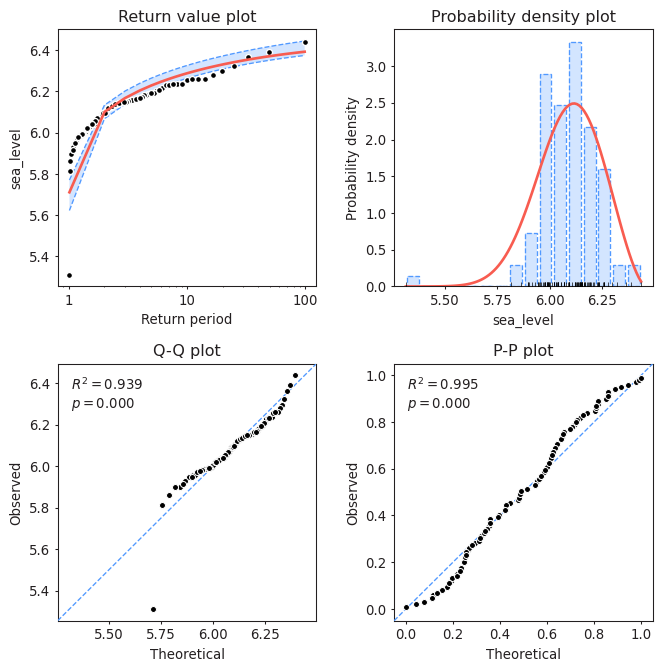

In [128]:
# Diagnostic plot
model.plot_diagnostic(alpha=0.95)